# Milestone 5: Merging the Data and Storing in a Database / Visualizing Data

For the initial step, I reran the code in each of the 3 milestone notebooks and used the following code at the end of each file to load them into the same SQLite databse.

In [ ]:
# ADDING CODE TO LOAD EACH MILESTONE DF INTO SQLite 
# This code chunk was run in the respective milestone notebook files - Just including here for visibility on steps taken

import sqlite3
import pandas as pd

# Connect to (or create) the SQLite database
conn = sqlite3.connect("combined_data.db")  # Ensure all notebooks use the same filename

# Write the DataFrame to a table in SQLite
#Changed the df reference in each file
filtered_df.to_sql("country_api", conn, if_exists="replace", index=False)
web_df_melted.to_sql("gdp_web", conn, if_exists="replace", index=False)
csv_aggregated.to_sql("covid_csv", conn, if_exists="replace", index=False)

# Close the connection
conn.close()

In [14]:
#Step to query all 3 together
import sqlite3
import pandas as pd

conn = sqlite3.connect("combined_data.db")

query = """
SELECT a.country, c.region, a.year, a.new_cases, a.new_deaths, a.people_vaccinated, b.GDP, c.population, 
c.urban_population_percentage, c.internet_users_percentage, c.tourism_rate
FROM covid_csv a
JOIN gdp_web b ON a.country = b.'Country Name' AND a.year = b.Year
JOIN country_api c ON a.country = c.country_name;
"""

df_combined = pd.read_sql(query, conn)
conn.close()

#Show the combined dataframe
display(df_combined) 

,country,region,year,new_cases,new_deaths,people_vaccinated,GDP,population,urban_population_percentage,internet_users_percentage,tourism_rate
0,Afghanistan,Southern Asia,2020,52330.0,2189.0,0.0,1.995593e+10,38928.0,25.8,13.5,0.045803
1,Afghanistan,Southern Asia,2021,105729.0,5167.0,4142857.0,1.426650e+10,38928.0,25.8,13.5,0.045803
2,Afghanistan,Southern Asia,2022,49495.0,493.0,11459692.0,1.450216e+10,38928.0,25.8,13.5,0.045803
3,Afghanistan,Southern Asia,2023,22821.0,124.0,19151368.0,NaN,38928.0,25.8,13.5,0.045803
4,Albania,Southern Europe,2020,57146.0,1170.0,19151368.0,1.516273e+10,2878.0,61.2,71.8,1.855455
...,...,...,...,...,...,...,...,...,...,...,...
723,Zambia,Eastern Africa,2023,15108.0,46.0,11711565.0,2.816263e+10,18384.0,44.1,14.3,0.058312
724,Zimbabwe,Eastern Africa,2020,13625.0,360.0,11711565.0,2.150970e+10,14863.0,32.2,27.1,0.173585
725,Zimbabwe,Eastern Africa,2021,198103.0,4637.0,11711565.0,2.837124e+10,14863.0,32.2,27.1,0.173585
726,Zimbabwe,Eastern Africa,2022,48372.0,640.0,6437808.0,2.736663e+10,14863.0,32.2,27.1,0.173585


In [16]:
#Aggregate COVID (Flatfile) data by Region (From API data)

# Group by 'region' and 'year', summing up'new_cases' and 'new_deaths'
df_region_summary = df_combined.groupby(['region', 'year'])[['new_cases', 'new_deaths']].sum().reset_index()

# Display the summarized DataFrame
display(df_region_summary)

,region,year,new_cases,new_deaths
0,Caribbean,2020,302871.0,5006.0
1,Caribbean,2021,1610854.0,15550.0
2,Caribbean,2022,1438466.0,4296.0
3,Caribbean,2023,123523.0,550.0
4,Central America,2020,2220743.0,163361.0
...,...,...,...,...
83,Western Asia,2023,244143.0,1764.0
84,Western Europe,2020,6266222.0,156973.0
85,Western Europe,2021,17366746.0,163708.0
86,Western Europe,2022,75379160.0,99941.0


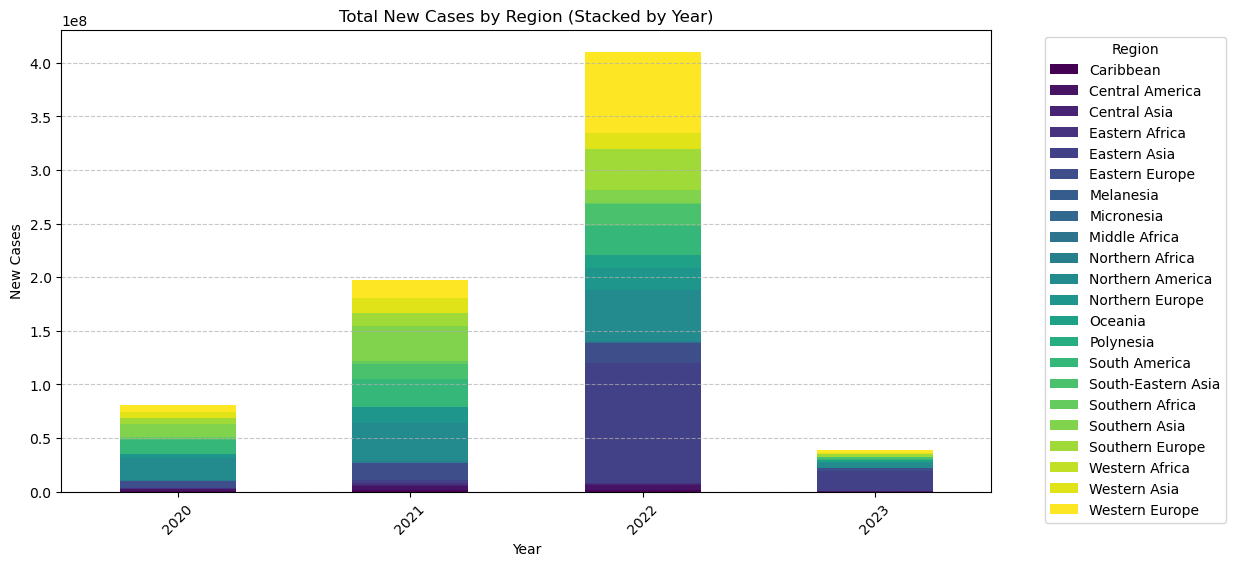

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot the data for stacked bar chart
df_pivot_cases = df_region_summary.pivot(index='year', columns='region', values='new_cases')

# Plot stacked bar chart
df_pivot_cases.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6))
plt.title("Total New Cases by Region (Stacked by Year)")
plt.xlabel("Year")
plt.ylabel("New Cases")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

I'm finding this visualization to be too granular to derive any insights. I didn't foresee this during the weekly milestone but I will now group these regions into their continents to see if that yields better visualizations.

In [22]:
#Try grouping regions into continent for less granularity
# Define a mapping of regions to continents
region_to_continent = {
    "Caribbean": "Americas", "Central America": "Americas", "South America": "Americas", "Northern America": "Americas",
    "Central Asia": "Asia", "Eastern Asia": "Asia", "South-Eastern Asia": "Asia", "Southern Asia": "Asia", "Western Asia": "Asia",
    "Eastern Europe": "Europe", "Northern Europe": "Europe", "Southern Europe": "Europe", "Western Europe": "Europe",
    "Eastern Africa": "Africa", "Middle Africa": "Africa", "Northern Africa": "Africa", "Southern Africa": "Africa", "Western Africa": "Africa",
    "Melanesia": "Oceania", "Micronesia": "Oceania", "Oceania": "Oceania", "Polynesia": "Oceania"
}

# Map regions to continents
df_combined["continent"] = df_combined["region"].map(region_to_continent)

# Aggregate by continent and year
df_continent_summary = df_combined.groupby(["continent", "year"])[["new_cases", "new_deaths"]].sum().reset_index()

# Display the grouped DataFrame
display(df_continent_summary)


,continent,year,new_cases,new_deaths
0,Africa,2020,2669053.0,63932.0
1,Africa,2021,6845875.0,161426.0
2,Africa,2022,2646449.0,28646.0
3,Africa,2023,120834.0,518.0
4,Americas,2020,35653734.0,954622.0
5,Americas,2021,67569392.0,1451724.0
6,Americas,2022,81611285.0,473596.0
7,Americas,2023,6761835.0,106167.0
8,Asia,2020,20090329.0,331697.0
9,Asia,2021,62593466.0,906690.0


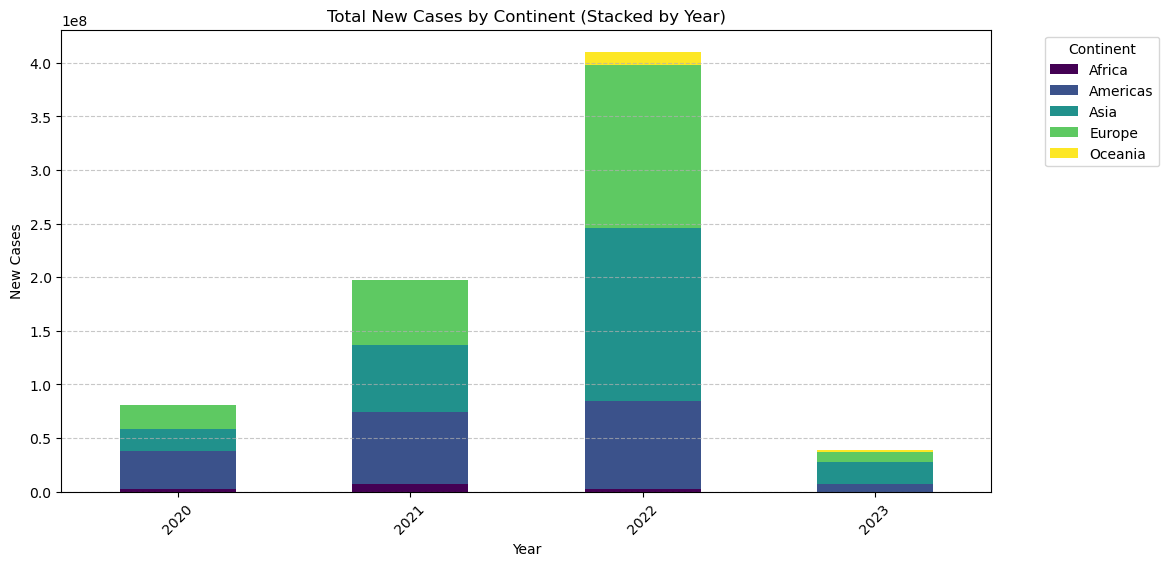

In [24]:
df_pivot_continent = df_continent_summary.pivot(index='year', columns='continent', values='new_cases')

df_pivot_continent.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6))
plt.title("Total New Cases by Continent (Stacked by Year)")
plt.xlabel("Year")
plt.ylabel("New Cases")
plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

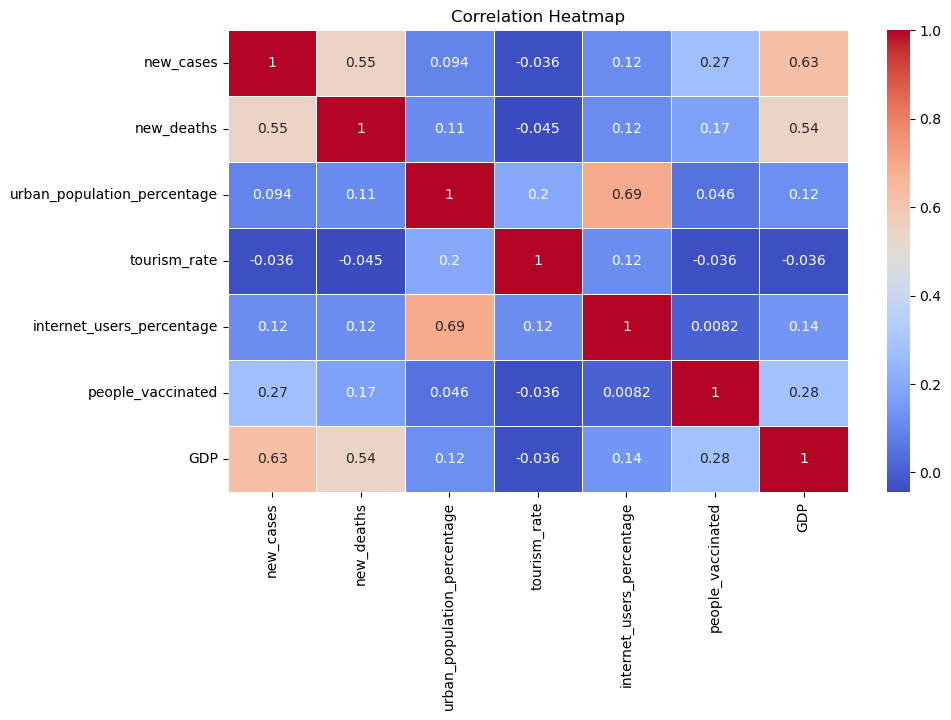

In [46]:
# Check correlation between these variables across all countries

plt.figure(figsize=(10, 6))
sns.heatmap(df_combined[["new_cases", "new_deaths", "urban_population_percentage", "tourism_rate", "internet_users_percentage", "people_vaccinated", "GDP"]].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

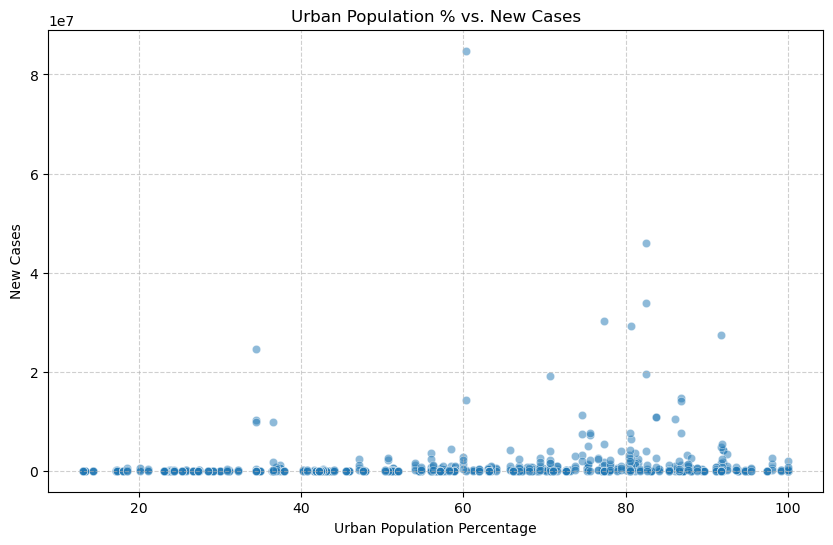

In [38]:
# Now I'd like to explore relationships between urban population (Country API) and new cases (COVID flatfile)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_combined, x="urban_population_percentage", y="new_cases", alpha=0.5)
plt.title("Urban Population % vs. New Cases")
plt.xlabel("Urban Population Percentage")
plt.ylabel("New Cases")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

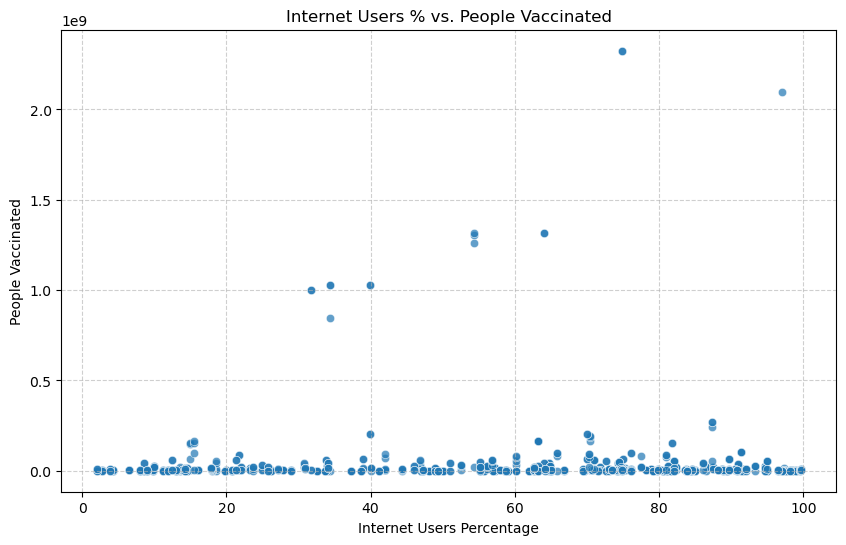

In [34]:
# Plot to see if better internet access (Country API) led to higher vaccination rates (Covid flat file)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_combined, x="internet_users_percentage", y="people_vaccinated", alpha=0.7)
plt.title("Internet Users % vs. People Vaccinated")
plt.xlabel("Internet Users Percentage")
plt.ylabel("People Vaccinated")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

The two scatter plots above, as we may have predicted from the correlation heatmap, did not yield any strong correlations between the variables selected. Next, I will move on to creating line charts to identify any patterns by year.

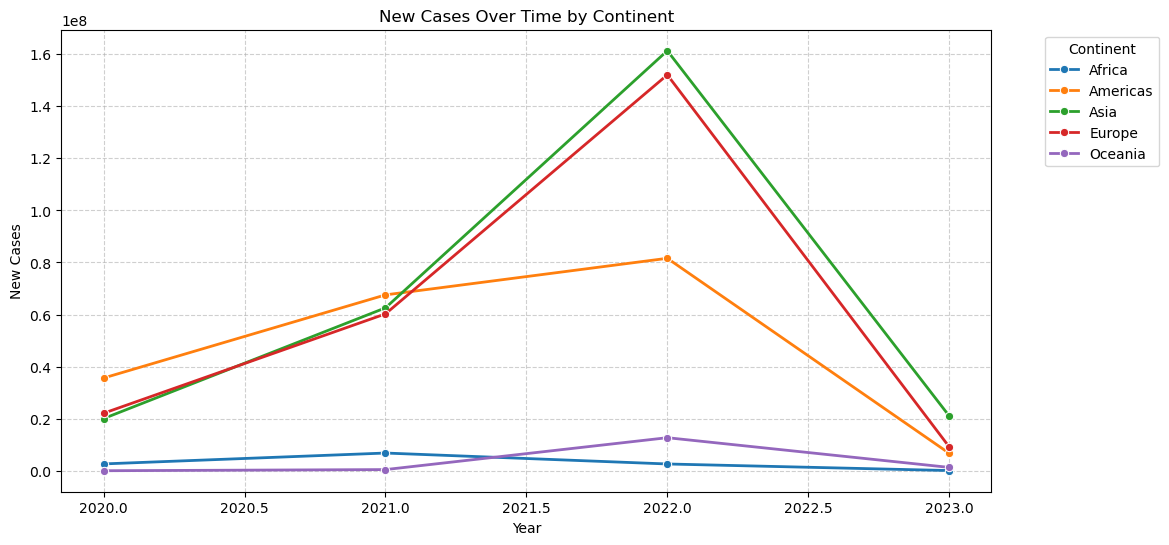

In [63]:
# Aggregate: Sum new cases by continent and year
df_continent_yearly = df_combined.groupby(["continent", "year"])[["new_cases"]].sum().reset_index()

# Plot new cases by continent over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_continent_yearly, x="year", y="new_cases", hue="continent", marker="o", linewidth=2)

# Formatting
plt.title("New Cases Over Time by Continent")
plt.xlabel("Year")
plt.ylabel("New Cases")
plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


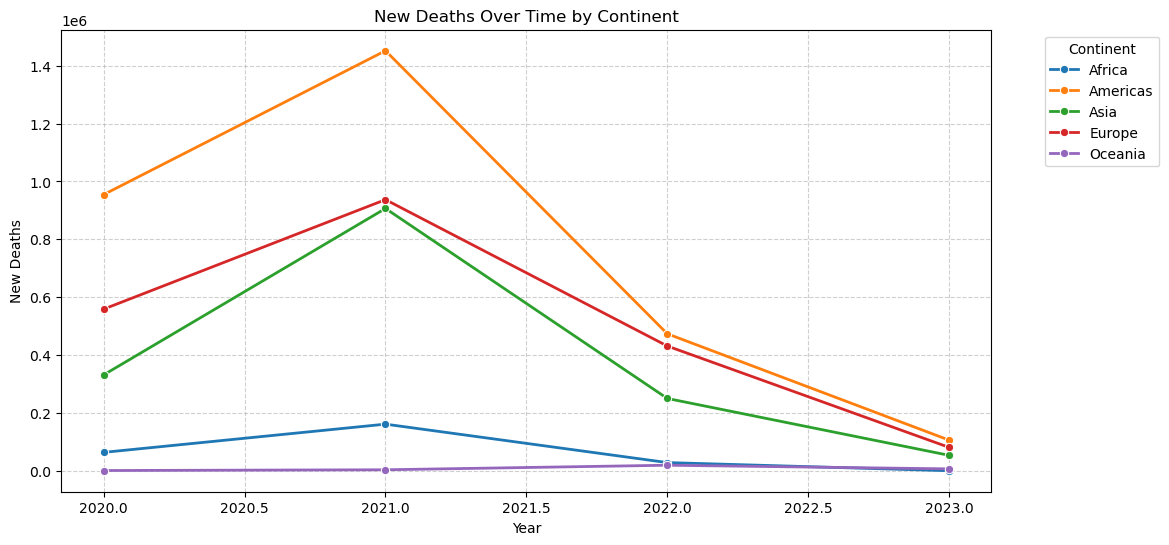

In [56]:
# Aggregate: Sum new cases by continent and year
df_continent_yearly = df_combined.groupby(["continent", "year"])[["new_deaths"]].sum().reset_index()


# Plot new cases by continent over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_continent_yearly, x="year", y="new_deaths", hue="continent", marker="o", linewidth=2)

# Formatting
plt.title("New Deaths Over Time by Continent")
plt.xlabel("Year")
plt.ylabel("New Deaths")
plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


All continents appear to have a peak of new deaths in 2021, followed by a rapid decline in 2022 and 2023. This is in line with the global COVID cases where many counties had big surges before vaccinations were widely available. Among the continents, it can be observed that the Americas had the highest death toll, which is consistent with the fact that the USA and Brazil had major outbreaks. On the other hand, we can see that Africa and Oceania had the lowest death rates according to data. Africa may have had lower reported cases, but it could also be that they have a much younger population and vast rural areas could have helped limit the spread. 

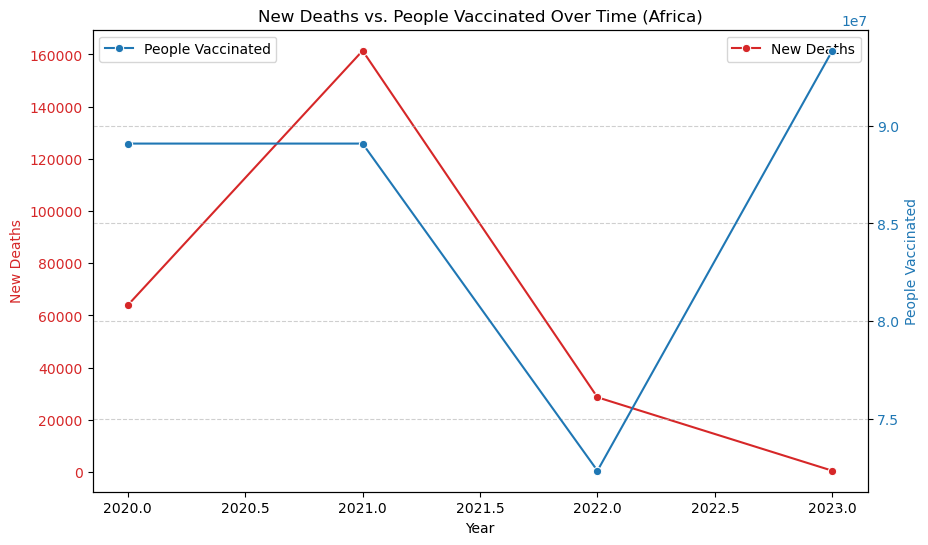

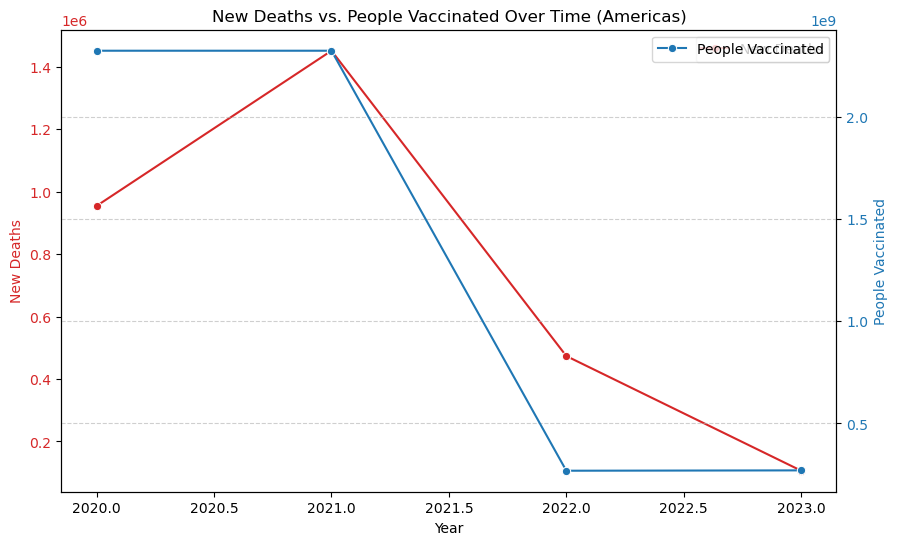

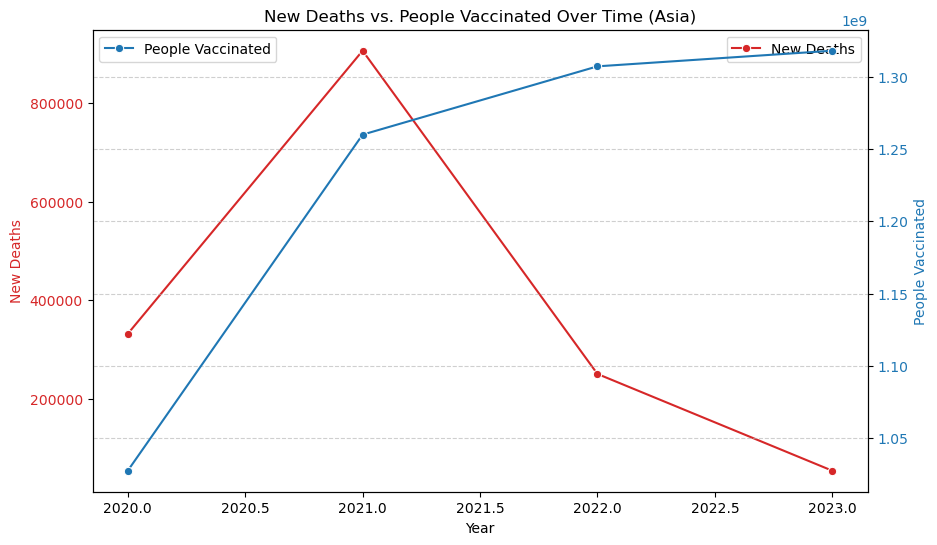

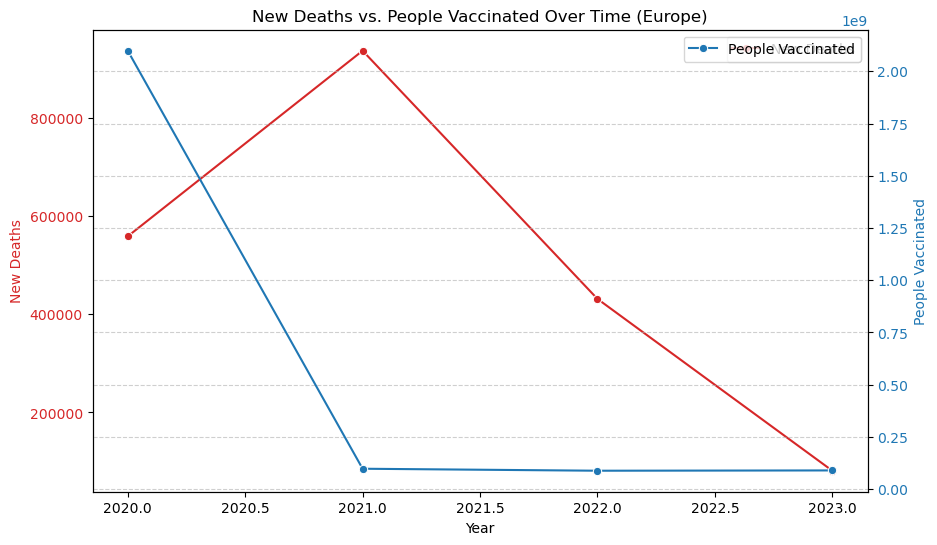

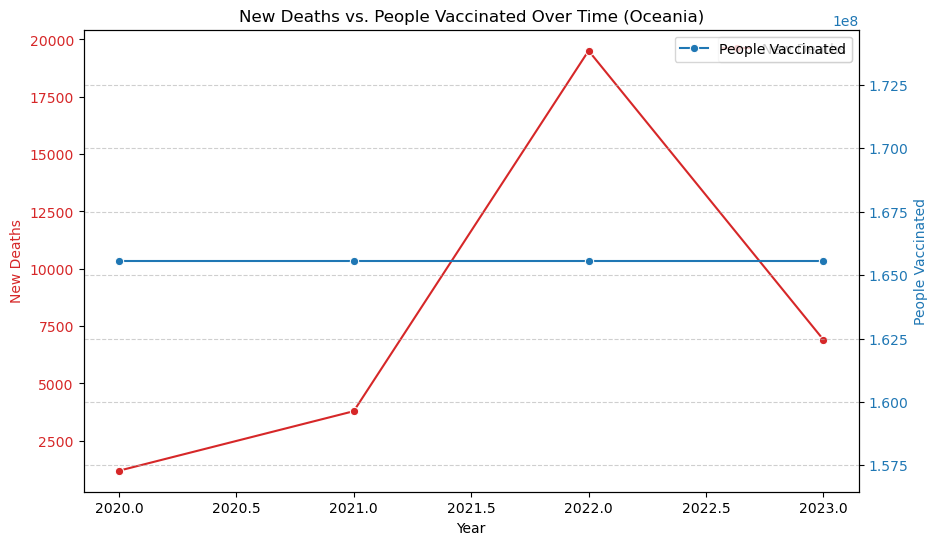

In [66]:
#Based on the information above, I am going to overlay the vaccinations by year and plot them by continent to see if there's a correlation
#between new deaths over time and people vaccinated.

# Aggregate: Sum new deaths and max vaccinations by year and continent
df_continent_yearly = df_combined.groupby(["continent", "year"]).agg({
    "new_deaths": "sum",  # Sum new deaths per year
    "people_vaccinated": "max"  # Max vaccination count (since it's already cumulative)
}).reset_index()

# Create separate plots for each continent
continents = df_continent_yearly["continent"].unique()

for continent in continents:
    plt.figure(figsize=(10, 6))
    
    # Filter data for the specific continent
    df_subset = df_continent_yearly[df_continent_yearly["continent"] == continent]
    
    # Create first y-axis (New Deaths)
    ax1 = sns.lineplot(data=df_subset, x="year", y="new_deaths", marker="o", color="tab:red", label="New Deaths")
    ax1.set_ylabel("New Deaths", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")
    
    # Create second y-axis (People Vaccinated)
    ax2 = ax1.twinx()
    sns.lineplot(data=df_subset, x="year", y="people_vaccinated", marker="o", ax=ax2, color="tab:blue", label="People Vaccinated")
    ax2.set_ylabel("People Vaccinated", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")
    
    # Formatting
    plt.title(f"New Deaths vs. People Vaccinated Over Time ({continent})")
    ax1.set_xlabel("Year")
    plt.grid(True, linestyle="--", alpha=0.6)
    
    # Show plot
    plt.show()

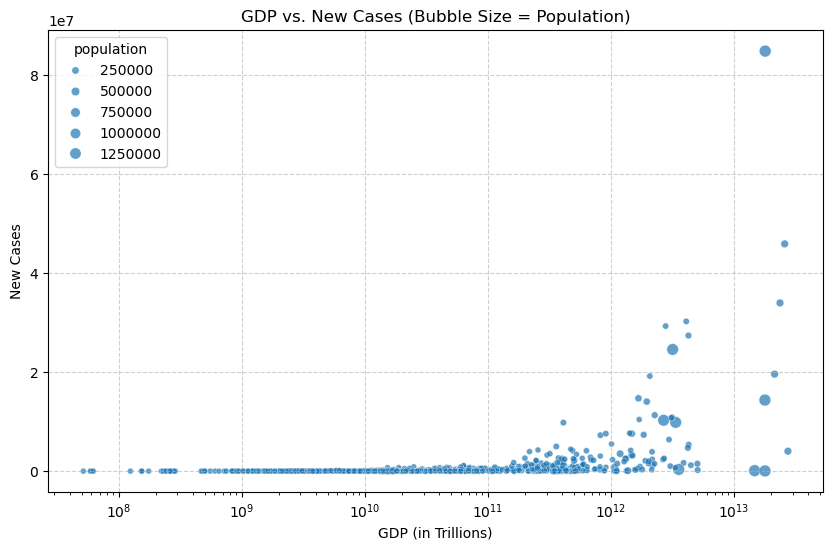

In [60]:
# SCatter plot to check if richer countries had more or fewer cases

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_combined, x="GDP", y="new_cases", size="population", alpha=0.7)
plt.title("GDP vs. New Cases (Bubble Size = Population)")
plt.xlabel("GDP (in Trillions)")
plt.ylabel("New Cases")
plt.xscale("log")  # Log scale for better visualization
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

This scatterplot shows us that many countries have lower GDP and relatively fewer COVID cases, while countries with high GDP had some of the highest case counts. This could be true with higher GDP countries having more urbanization and mobility (travel) that could have lead to more spread, but it could also mean that higher GDP countries had more testing and better reporting. The pattern observed here alone is not strong enough to draw any strong colusions on the correlation.

# Conclusion  

For this project, I cleaned and transformed data from 3 sources, including a flat file with COVID 19 statistics, a website with GDP data, and an API with country demographics/economic indicators. In this final step, I loaded the 3 datasets into a relational database management system (SQLite) and joined them together with joins into 1 cohesive dataset. Throughout this notebook, I used that merged dataset and created various visualizations utilizing matplotlib and seaborn to explore the relationships and patterns among these variables.  

The key transformations in previous weeks included datatype adjustments, missing value imputation, data filtering, format standardization, and adding calculated fields. While these changes improved data consistency and readability, they also raised ethical considerations related to bias, transparency, accuracy, and legal compliance.

## Lessons Learned  

One recurring lesson that I took away from this project is that data wrangling is not a linear process. Often times in each milestone, I had to perform a step, such as transforming the data type, only to have to do it again a few steps later when I calculated a new variable. Another example is when handling missing values, where I later recognized they were not random, and I had to go back and drop these rows instead. Overall, it is a highly iterative and non-linear process, and when you gain new insights, or realize errors, it is important to go back and revisit previous steps.   

## Ethical Implications  

A number of changes were made to improve the data usability and readability, including handling missing values, filtering out unnecessary data, standardizing formats, and adding calculated fields. As an example, I used forward-fillinng vaccination numbers, and replaced $0 GDP values with NaN, and filled i missing demographic data using the median value. While these changes improved the consistency of my data, it also introduced some concerns around transparency and misrepresentation. 

Since these datasets contain public health, economic, and demographic data, legal and regulartory guidelines such as the GDPR and HIPAA were considered. However, because the data was pre-aggregated and did not contain any personally identifiable information, strict compliance was not required in this project. However, ethical best practices should always be prioritized, including ensuring data integrity, avoiding misleading conlusions, and acknoledging biases. Additionally, the GDP dataset from the MacroTrends website discourages automated data extraction, so compliace with these terms of service and proper data access should be a strong consideration for any further research.

Assumptions played a key role in the data transformations I performed. The forward-fill for vaccinations assumed data consistency, and using the median to fill missing demographic data assumed uniformity across countries, which may not be true in the real world. Also, replacing $0 GDP values as missing assumed those values were incorrect instead of representing actual economic trends. These assumptions could impact analytics insights if they were incorrect. 

Regarding credibility, all the datasets used were pulled from publicly available repositories, and while the COVID-19 and World Bank data is considered reliable, we did discover that API Ninjas did not fully discolose its data origins, which raises some concern over the credibility. Additionally, if there were any errors in original data, we could be propagating them through these transformation steps. 

To avoid or reduce any ethical risks, it is important to document and have transparency in all steps taken, validate data against credible sources, and also to acknowledge the limitations in the analysis and conclusions we can draw from the resulting data. By following these steps, we can ensure responsible and ethical data handling, which is an important step in data science.